# 1. The data and the expiry calendar

**What this notebook does, in plain words**
- Loads daily prices of four Indian stock indices, 2014 to July 2026.
- Builds the *expiry calendar*: for every trading day, whose options expire that day.
- Checks that calendar against the exchanges' own contract files.
- Shows how much option trading now happens on the expiry day itself.

**Words used below**
- **Option expiry:** the last day an option contract exists. At the close of that day, it is settled against the index's *closing value*.
- **Weekly / monthly expiry:** weekly contracts expire every week on a fixed weekday. The monthly contract expires on the last such weekday of the month.
- **Natural experiment:** something outside our control changes for one group but not another, so we can compare. Here the exchanges kept changing the expiry weekday (see Table 1).

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
from expiryvol import data, expiries as ex, estimate as es, mechanisms as me, forecast as fc, plots
from expiryvol.features import build_panel
DATA, RES, FIG = ROOT / "data", ROOT / "results", ROOT / "figures"
pct = lambda b: 100 * (np.exp(b) - 1)   # log-variance difference -> % change in variance

In [2]:
prices, dropped = data.load_all_daily(DATA)          # downloads from Yahoo on the first run
td = data.trading_days("2013-06-03", data.DATA_END)  # exchange trading days (holiday list in expiryvol/holidays.py)
table = ex.expiry_table(td)                          # which option product expires on which day
panel = build_panel(prices, table, data.INDICES, data.STUDY_START, data.STUDY_END)
print(f"{len(panel):,} index-days, {panel['date'].min().date()} to {panel['date'].max().date()}")

12,312 index-days, 2014-01-01 to 2026-07-31


## The calendar rules (Table 1 of the paper)
Every row is one rule, valid from its start date until the next row. Each change is one natural experiment.

In [3]:
ex.rules_table()

,product,from,to,weekly,monthly,note
0,NIFTY,2000-01-01,2019-02-10,-,last Thu,monthly contracts only
1,NIFTY,2019-02-11,2025-08-31,Thu,last Thu,weekly options launched 11 Feb 2019 (Thursday)
2,NIFTY,2025-09-01,,Tue,last Tue,NSE moves all expiries to Tuesday (last Thursd...
3,BANKNIFTY,2000-01-01,2016-05-26,-,last Thu,monthly contracts only
4,BANKNIFTY,2016-05-27,2023-09-03,Thu,last Thu,weekly options launched 27 May 2016 (Thursday)
5,BANKNIFTY,2023-09-04,2024-02-29,Wed,last Thu,weekly moved to Wednesday (first 6 Sep 2023); ...
6,BANKNIFTY,2024-03-01,2024-11-19,Wed,last Wed,monthly moved to last Wednesday (first 27 Mar ...
7,BANKNIFTY,2024-11-20,2025-01-01,-,last Wed,weekly contracts discontinued (SEBI; last week...
8,BANKNIFTY,2025-01-02,2025-08-31,-,last Thu,"monthly moved to last Thursday (NSE circular, ..."
9,BANKNIFTY,2025-09-01,,-,last Tue,monthly moved to last Tuesday


## Does the calendar match what really happened?
- For Nifty and Bank Nifty we compare with NSE's daily contract files ("bhavcopy"). A day counts as an expiry day if a contract traded on its own expiry date.
- For Sensex we compare with the expiry dates in a 1-minute option dataset.
- The result: **0 mismatches**. The few calendar days not checked are days missing from the files.

In [4]:
pd.read_csv(RES / 'calendar_check.csv')

,product,source,from,to,expiry_days_rule,expiry_days_files,mismatches,rule_days_not_in_files
0,NIFTY,NSE bhavcopy,2014-01-01,2026-06-29,444,444,0,"2020-11-05, 2020-11-12"
1,BANKNIFTY,NSE bhavcopy,2014-01-01,2026-06-29,488,488,0,"2020-11-05, 2020-11-12"
2,SENSEX,1-minute option files (expiry dates),2023-08-11,2026-07-30,156,148,0,"2024-10-31, 2025-10-30, 2026-05-27, 2026-06-04..."


## Example: the September 2025 swap
NSE moved Nifty from Thursday to Tuesday, and BSE moved Sensex from Tuesday to Thursday, on the same date.

In [5]:
for product in ["NIFTY", "SENSEX"]:
    e = ex.expiry_dates(product, td, "2025-08-18", "2025-09-12")
    print(product, ", ".join(e["date"].dt.strftime("%a %d %b")))

NIFTY Thu 21 Aug, Thu 28 Aug, Tue 02 Sep, Tue 09 Sep
SENSEX Tue 19 Aug, Tue 26 Aug, Thu 04 Sep, Thu 11 Sep


## Cleaning log
- Rows dropped from the price data, and why.
- "Not a normal session" means a Saturday special session or a Diwali *Muhurat* evening session.

In [6]:
data.summarize_dropped(dropped)

reason,not a normal session,stale bar
series,,
banknifty,6,1
indiavix,6,0
midcap50,6,0
nifty50,7,0
sensex,6,0


## How big is expiry-day trading?
- The figure shows the share of a whole year's option contracts that were traded on an expiry day, in the contract expiring that day.
- Such contracts are called "0DTE", zero days to expiry.
- For Nifty this share was about 9–11% in 2014–18 and reached 59% in 2024, after weekly options arrived (Feb 2019).

,index,year,share_0dte_of_year,share_expiring_on_expiry_days,expiry_days
0,banknifty,2014,0.137,0.939,12
1,banknifty,2015,0.127,0.942,12
2,banknifty,2016,0.343,0.906,36
3,banknifty,2017,0.415,0.925,52
4,banknifty,2018,0.437,0.935,52
5,banknifty,2019,0.445,0.949,52
6,banknifty,2020,0.459,0.964,51
7,banknifty,2021,0.414,0.956,52
8,banknifty,2022,0.439,0.959,52
9,banknifty,2023,0.500,0.966,52


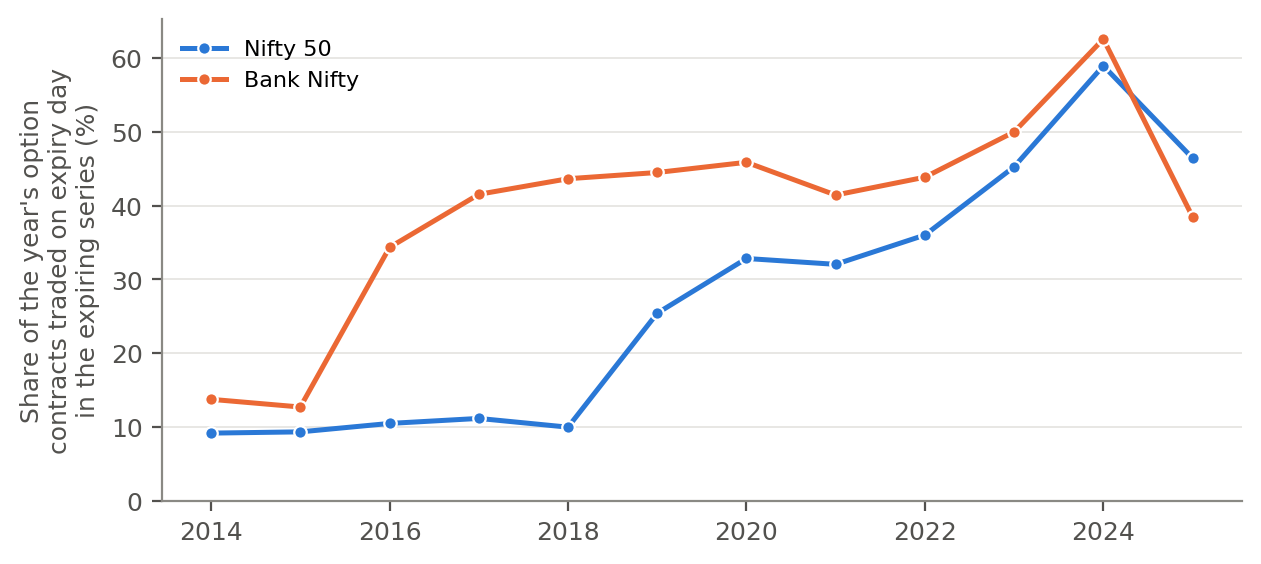

In [7]:
display(pd.read_csv(RES / 'option_activity_by_year.csv').round(3))
Image(FIG / 'fig1_activity.png')

## Do the 1-minute bars agree with the daily data?
- The daily high and low rebuilt from 1-minute bars match Yahoo's daily bars almost perfectly. The correlation of the daily ranges is 0.996–0.999.
- So we can trust the 1-minute data for the intraday analysis.

In [8]:
pd.read_csv(RES / 'minute_vs_daily.csv')

,index,days,corr_log_range
0,nifty50,1248,0.998741
1,banknifty,1252,0.998530
2,sensex,927,0.996167
